<div style="background:linear-gradient(135deg, rgba(249,112,102,0.18), rgba(249,112,102,0.02)); border-left:6px solid #F97066; border-radius:10px; padding:20px 24px; margin-bottom:20px;">
<h1 style="margin:0; color:#F97066; font-size:1.8em;">🔧 Pipelines y Evaluación Rigurosa de Modelos</h1>
<p style="margin:6px 0 0; opacity:0.8;">Unidad 3 — <code>Pipeline</code>, <code>ColumnTransformer</code>, validación cruzada y métricas más allá de accuracy</p>
</div>

En <code>2-introduccion-machine-learning.ipynb</code>, la búsqueda de hiperparámetros con <code>GridSearchCV</code> y <code>RandomizedSearchCV</code> se aplicó siempre sobre un k-NN "crudo": sin ningún paso de preprocesamiento, y evaluado únicamente con accuracy. Ese enfoque es razonable para introducir el concepto, pero deja dos huecos importantes que este notebook cierra: (1) en un proyecto real casi siempre hay que imputar, escalar y codificar variables antes de entrenar, y esas transformaciones deben integrarse en el proceso de búsqueda y validación sin filtrar información del conjunto de prueba; y (2) accuracy es, en general, una métrica insuficiente — especialmente cuando las clases están desbalanceadas.

Para la primera parte se reutiliza el mismo dataset sintético de crédito bancario de <code>1-AI-fundamentals/5-data-preprocessing.ipynb</code>, que ya enseñó a evitar la fuga de datos ajustando manualmente cada imputador/escalador/codificador solo con <code>X_train</code>. Aquí se muestra cómo <code>Pipeline</code> y <code>ColumnTransformer</code> automatizan exactamente esa misma disciplina. Para la segunda parte (métricas y clases desbalanceadas) se usa un segundo dataset sintético, deliberadamente desbalanceado (95&nbsp;%/5&nbsp;%), generado con <code>make_classification</code>.

<div style="border:1px solid rgba(14,165,233,0.35); border-radius:10px; padding:14px 20px; margin:16px 0 24px; background:rgba(14,165,233,0.04);">
<strong>📑 Contenido de esta guía</strong>
<ol style="margin:8px 0 0; padding-left:20px;">
<li><a href="#por-que-pipeline">¿Por qué usar <code>Pipeline</code>?</a></li>
<li><a href="#columntransformer"><code>ColumnTransformer</code> con el dataset de crédito</a></li>
<li><a href="#validacion-cruzada">Validación cruzada del Pipeline completo</a></li>
<li><a href="#grid-search"><code>GridSearchCV</code> sobre el Pipeline completo</a></li>
<li><a href="#metricas">Métricas de evaluación más allá de accuracy</a></li>
<li><a href="#curvas">Curvas de aprendizaje y de validación</a></li>
<li><a href="#desbalance">Clases desbalanceadas</a></li>
<li><a href="#cierre">Cierre y próximos pasos</a></li>
</ol>
</div>

<a id="por-que-pipeline"></a>

# <span style="color:#F97066;">1.</span> ¿Por qué usar <code>Pipeline</code>?

Un <code>Pipeline</code> de <code>scikit-learn</code> encadena una secuencia de pasos (por ejemplo, imputación → escalado → codificación → clasificador) y los trata como un único estimador: tiene sus propios métodos <code>fit</code>, <code>predict</code> y <code>score</code>. Esto aporta dos beneficios centrales:

- **Evita la fuga de datos (*data leakage*) por construcción.** En <code>5-data-preprocessing.ipynb</code> se insistió en que cada transformación (imputador, escalador, codificador) debe ajustarse (<code>fit</code>) únicamente con <code>X_train</code>. Hacerlo manualmente, paso por paso, funciona pero es fácil de romper por error (por ejemplo, llamando <code>fit_transform</code> sobre el dataset completo antes de dividirlo). Un <code>Pipeline</code> hace que esa disciplina sea automática: al llamar <code>pipeline.fit(X_train, y_train)</code>, cada paso interno se ajusta solo con esos datos, y <code>pipeline.predict(X_test)</code> aplica (nunca reajusta) esos mismos parámetros aprendidos.
- **Simplifica el código.** En lugar de mantener por separado un imputador, un escalador, un codificador y un modelo — y recordar aplicar cada uno en el orden correcto tanto a entrenamiento como a prueba — el <code>Pipeline</code> se trata como un solo objeto en <code>cross_validate</code>, <code>GridSearchCV</code> o al guardar el modelo con <code>joblib</code>.

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
El beneficio de evitar la fuga de datos se vuelve especialmente importante en validación cruzada: si el escalador se ajusta <em>antes</em> de dividir en folds, cada fold de validación "ve" información (la media, la desviación estándar) calculada con datos que incluyen su propio fold de prueba. Con un <code>Pipeline</code> dentro de <code>cross_validate</code> o <code>GridSearchCV</code>, cada fold ajusta su propio preprocesamiento de forma independiente — el mismo principio de <code>5-data-preprocessing.ipynb</code>, aplicado automáticamente en cada partición.
</div>

---

<a id="columntransformer"></a>

# <span style="color:#F97066;">2.</span> <code>ColumnTransformer</code> con el dataset de crédito

El dataset de crédito bancario tiene columnas numéricas (<code>edad</code>, <code>antiguedad_laboral</code>, <code>ingreso_anual</code>, <code>puntaje_crediticio</code>) y categóricas (<code>ciudad</code>, <code>nivel_educativo</code>), que requieren transformaciones distintas: las numéricas se imputan y escalan, las categóricas se codifican. <code>ColumnTransformer</code> permite declarar, en un solo objeto, qué transformación aplicar a qué subconjunto de columnas — el equivalente automatizado de lo que en <code>5-data-preprocessing.ipynb</code> se hizo manualmente columna por columna.

<span style="color:#F97066;">2.1</span> Generación del dataset y división en entrenamiento y prueba

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

np.random.seed(42)
n = 300

# 1. Generar el dataset sintético de crédito bancario
#    (mismo generador que en ../AI-fundamentals/5-data-preprocessing.ipynb, para mantener continuidad)
edad = np.random.randint(18, 70, size=n).astype(float)
antiguedad_laboral = np.clip((edad - 18) * 0.18 + np.random.exponential(scale=2.0, size=n), 0, None)
antiguedad_laboral = np.round(antiguedad_laboral, 1)
base_log_ingreso = 9.9 + 0.03 * antiguedad_laboral + 0.004 * edad
ingreso_anual = np.round(np.exp(base_log_ingreso + np.random.normal(0, 0.28, size=n)))
idx_outliers = np.random.choice(n, size=6, replace=False)
ingreso_anual[idx_outliers] = ingreso_anual[idx_outliers] * 7
puntaje_crediticio = (
    520 + 0.0016 * np.clip(ingreso_anual, 0, 120000) + 4.5 * antiguedad_laboral
    + np.random.normal(0, 35, size=n)
)
puntaje_crediticio = np.round(np.clip(puntaje_crediticio, 300, 850))
ciudad = np.random.choice(["Bogotá", "Medellín", "Cali", "Barranquilla"], size=n, p=[0.4, 0.3, 0.2, 0.1])
nivel_educativo = np.random.choice(["Secundaria", "Pregrado", "Posgrado"], size=n, p=[0.3, 0.5, 0.2])
z = -12.0 + 0.016 * puntaje_crediticio + 0.00007 * np.clip(ingreso_anual, 0, 120000) + 0.09 * antiguedad_laboral
aprobado = np.random.binomial(1, 1 / (1 + np.exp(-z)))

df = pd.DataFrame({
    "edad": edad,
    "antiguedad_laboral": antiguedad_laboral,
    "ingreso_anual": ingreso_anual,
    "puntaje_crediticio": puntaje_crediticio,
    "ciudad": ciudad,
    "nivel_educativo": nivel_educativo,
    "aprobado": aprobado,
})

# 2. Separar características (X) y objetivo (y), y dividir en entrenamiento y prueba
#    ANTES de cualquier preprocesamiento (mismo principio de 5-data-preprocessing.ipynb)
X = df.drop(columns=["aprobado"])
y = df["aprobado"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} filas | Prueba: {X_test.shape[0]} filas")
df.head()

Entrenamiento: 240 filas | Prueba: 60 filas


,edad,antiguedad_laboral,ingreso_anual,puntaje_crediticio,ciudad,nivel_educativo,aprobado
0,56.0,11.1,39599.0,596.0,Cali,Pregrado,1
1,69.0,9.6,26175.0,629.0,Medellín,Pregrado,0
2,46.0,5.7,19464.0,571.0,Cali,Pregrado,0
3,32.0,4.9,22441.0,549.0,Cali,Posgrado,0
4,60.0,11.3,28438.0,697.0,Medellín,Posgrado,1


<span style="color:#F97066;">2.2</span> Construcción del <code>ColumnTransformer</code> y el <code>Pipeline</code> completo

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
Esta variante del dataset no genera valores faltantes explícitamente (a diferencia de la usada en <code>5-data-preprocessing.ipynb</code>). Aun así, se incluye un paso de imputación en el <code>ColumnTransformer</code>: en un flujo de producción, datos futuros podrían llegar con valores nulos, y conviene que el <code>Pipeline</code> esté preparado para ese caso sin requerir cambios de código.
</div>

Se elige <code>RandomForestClassifier</code> como clasificador para este <code>Pipeline</code> principal: ya fue introducido en <code>2-introduccion-machine-learning.ipynb</code> (sección de modelos de ensamble), así que no es un modelo nuevo que aprender, y maneja bien la combinación de variables numéricas y categóricas codificadas one-hot sin ser especialmente sensible a la escala de las variables. Esto permite que este notebook se enfoque en los conceptos nuevos — <code>Pipeline</code>, <code>ColumnTransformer</code>, validación cruzada y métricas — en lugar de en un modelo nuevo.

In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

# 1. Definir columnas numéricas y categóricas
cols_numericas = ["edad", "antiguedad_laboral", "ingreso_anual", "puntaje_crediticio"]
cols_categoricas = ["ciudad", "nivel_educativo"]

# 2. Sub-pipeline de preprocesamiento numérico: imputar (media) y luego escalar
preprocesador_numerico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
])

# 3. ColumnTransformer: aplica cada preprocesamiento solo a sus columnas correspondientes
preprocesador = ColumnTransformer(transformers=[
    ("num", preprocesador_numerico, cols_numericas),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cols_categoricas),
])

# 4. Pipeline completo: preprocesamiento + clasificador, como un único estimador
pipeline_credito = Pipeline(steps=[
    ("preprocessor", preprocesador),
    ("classifier", RandomForestClassifier(random_state=42)),
])

# 5. Ajustar el pipeline completo SOLO con entrenamiento (imputador, escalador,
#    codificador y clasificador se ajustan todos aquí, en un único paso)
pipeline_credito.fit(X_train, y_train)

# 6. Evaluación rápida sobre prueba (accuracy solamente; ver la sección de métricas más adelante)
print(f"Accuracy en prueba: {pipeline_credito.score(X_test, y_test):.3f}")

Accuracy en prueba: 0.583


---

<a id="validacion-cruzada"></a>

# <span style="color:#F97066;">3.</span> Validación cruzada del Pipeline completo

Una sola división entrenamiento/prueba depende de qué observaciones cayeron por azar en cada conjunto. <code>StratifiedKFold</code> combinado con <code>cross_validate</code> permite validar el <code>Pipeline</code> completo con varias métricas a la vez, manteniendo en cada fold la misma proporción de clases que en el dataset original (importante incluso aquí, donde las clases no están muy desbalanceadas).

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
Se pasa <code>pipeline_credito</code> completo (no solo el clasificador) a <code>cross_validate</code>. Esto significa que, en cada uno de los 5 folds, el imputador, el escalador y el codificador se ajustan <strong>de nuevo</strong>, usando únicamente los datos de entrenamiento de ese fold — nunca los del fold de validación. No hay fuga de datos entre folds, tal como no la había entre <code>X_train</code> y <code>X_test</code> en <code>5-data-preprocessing.ipynb</code>.
</div>

In [3]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# 1. Definir la validación cruzada estratificada
cv_estratificado = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Definir varias métricas a calcular simultáneamente
metricas = ["accuracy", "f1", "roc_auc"]

# 3. Validar el PIPELINE COMPLETO (preprocesamiento + clasificador), no solo el clasificador
resultados_cv = cross_validate(
    pipeline_credito, X_train, y_train, cv=cv_estratificado, scoring=metricas
)

for metrica in metricas:
    valores = resultados_cv[f"test_{metrica}"]
    print(f"{metrica:9s}: media={valores.mean():.3f}  (+/- {valores.std():.3f})  por fold={np.round(valores, 3)}")

accuracy : media=0.708  (+/- 0.075)  por fold=[0.583 0.812 0.688 0.729 0.729]


f1       : media=0.724  (+/- 0.071)  por fold=[0.615 0.83  0.694 0.755 0.723]
roc_auc  : media=0.794  (+/- 0.058)  por fold=[0.689 0.868 0.802 0.807 0.802]


---

<a id="grid-search"></a>

# <span style="color:#F97066;">4.</span> <code>GridSearchCV</code> sobre el Pipeline completo

En <code>2-introduccion-machine-learning.ipynb</code>, <code>GridSearchCV</code> solo optimizaba hiperparámetros del clasificador (k-NN), sin ningún preprocesamiento de por medio. Como aquí el preprocesamiento vive dentro del mismo <code>Pipeline</code> que el clasificador, es posible optimizar simultáneamente hiperparámetros de <strong>ambos</strong>: por ejemplo, la estrategia de imputación (<code>mean</code> vs. <code>median</code>) junto con la profundidad y cantidad de árboles del <code>RandomForestClassifier</code>. Cada hiperparámetro se referencia con la sintaxis <code>nombre_del_paso__hiperparámetro</code> (y <code>nombre_del_paso__sub_paso__hiperparámetro</code> para pasos anidados, como el imputador dentro del <code>ColumnTransformer</code>).

In [4]:
from sklearn.model_selection import GridSearchCV

# 1. Espacio de búsqueda: hiperparámetros de preprocesamiento Y del modelo, a la vez
param_grid = {
    "preprocessor__num__imputer__strategy": ["mean", "median"],
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 5, 10],
}

# 2. GridSearchCV sobre el Pipeline completo, con validación cruzada estratificada, optimizando F1
grid_search = GridSearchCV(
    pipeline_credito, param_grid, cv=cv_estratificado, scoring="f1", n_jobs=-1, verbose=1
)

# 3. Ejecutar la búsqueda SOLO sobre entrenamiento
grid_search.fit(X_train, y_train)

# 4. Resultados
print(f"Mejores hiperparámetros encontrados:\n{grid_search.best_params_}")
print(f"Mejor F1 en validación cruzada: {grid_search.best_score_:.3f}")

# 5. El mejor pipeline (preprocesamiento + clasificador) ya ajustado con todo X_train
mejor_pipeline = grid_search.best_estimator_

Fitting 5 folds for each of 12 candidates, totalling 60 fits


Mejores hiperparámetros encontrados:
{'classifier__max_depth': 10, 'classifier__n_estimators': 200, 'preprocessor__num__imputer__strategy': 'mean'}
Mejor F1 en validación cruzada: 0.747


---

<a id="metricas"></a>

# <span style="color:#F97066;">5.</span> Métricas de evaluación más allá de accuracy

El notebook principal solo reporta *accuracy* (la fracción de predicciones correctas). Esa única cifra puede ocultar problemas importantes — por ejemplo, un modelo que acierta el 95&nbsp;% de las veces puede, aun así, fallar sistemáticamente en la clase que más interesa. Antes de ejecutar código, conviene fijar qué significa cada métrica.

<span style="color:#F97066;">5.1</span> La matriz de confusión: el punto de partida de todo lo demás

Para un problema binario, la matriz de confusión cruza la clase **real** de cada observación (filas) con la clase **predicha** por el modelo (columnas), en cuatro casillas:

<div style="border-radius:12px; overflow:hidden; border:1px solid rgba(14,165,233,0.35); margin:16px 0;">
<table style="width:100%; border-collapse:collapse; font-size:0.9em;">
<thead>
<tr style="background:#0EA5E9;">
<th style="text-align:left; padding:8px 14px; color:#ffffff;"></th>
<th style="text-align:left; padding:8px 14px; color:#ffffff;">Predicho: negativo</th>
<th style="text-align:left; padding:8px 14px; color:#ffffff;">Predicho: positivo</th>
</tr>
</thead>
<tbody>
<tr style="background:rgba(14,165,233,0.07);"><td style="padding:6px 14px;"><strong>Real: negativo</strong></td><td style="padding:6px 14px;">Verdadero negativo (TN)</td><td style="padding:6px 14px;">Falso positivo (FP)</td></tr>
<tr><td style="padding:6px 14px;"><strong>Real: positivo</strong></td><td style="padding:6px 14px;">Falso negativo (FN)</td><td style="padding:6px 14px;">Verdadero positivo (TP)</td></tr>
</tbody>
</table>
</div>

Todas las métricas de esta sección son, en el fondo, distintas formas de combinar estas cuatro cantidades.

<span style="color:#F97066;">5.2</span> Precisión (*precision*), exhaustividad (*recall*) y F1

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota — dos palabras, un mismo nombre en español</strong><br>
En este curso, "precisión" se ha usado hasta ahora como sinónimo de <strong>accuracy</strong> (por ejemplo, "Precisión en test: 0.978" en <code>1-fundamentos-redes-neuronales.ipynb</code>). A partir de aquí, "precisión" también nombra una métrica <strong>distinta</strong>: <em>precision</em>, una de las columnas de <code>classification_report</code>. Ambas comparten nombre en español, pero no son lo mismo — accuracy mide aciertos sobre el total de observaciones; precision mide aciertos sobre las veces que el modelo predijo la clase positiva. De aquí en adelante, cuando se hable de "precisión" en el sentido de esta sección, se aclarará explícitamente que se trata de la métrica <em>precision</em>.
</div>

Para la clase positiva:

$$\text{Precision} = \frac{TP}{TP + FP} \qquad \text{Recall} = \frac{TP}{TP + FN}$$

- **Precision** responde: *de las veces que el modelo predijo "positivo", ¿en cuántas acertó?* Una precisión baja significa muchas falsas alarmas (falsos positivos).
- **Recall** (también llamado sensibilidad o exhaustividad) responde: *de todos los casos que en realidad eran positivos, ¿a cuántos encontró el modelo?* Un recall bajo significa que se están dejando pasar muchos casos positivos reales (falsos negativos).

Estas dos métricas suelen estar en tensión: un modelo puede subir su recall (marcando "positivo" con más frecuencia) a costa de bajar su precision (más falsas alarmas), y viceversa. Cuál de las dos importa más depende del costo de cada tipo de error en el problema concreto — por ejemplo, en un diagnóstico médico un falso negativo (una enfermedad no detectada) suele ser mucho más costoso que un falso positivo (una prueba adicional innecesaria), así que ahí interesa maximizar recall incluso a costa de precision.

**F1-score** resume ambas en un solo número mediante su media armónica (penaliza fuertemente si una de las dos es muy baja, a diferencia del promedio simple):

$$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

<span style="color:#F97066;">5.3</span> Curva ROC y curva Precision-Recall

Un clasificador no produce directamente "positivo" o "negativo": produce una probabilidad, y se necesita un **umbral** (por defecto, 0.5) para convertirla en una clase. Cada umbral posible da una matriz de confusión distinta, y por lo tanto valores distintos de precision, recall, y de la tasa de falsos positivos.

- La **curva ROC** grafica la tasa de verdaderos positivos (recall) contra la tasa de falsos positivos, para todos los umbrales posibles. El área bajo la curva (**AUC**) resume la curva en un solo número: 0.5 equivale a adivinar al azar, 1.0 a una separación perfecta entre clases.
- La **curva Precision-Recall** grafica precision contra recall para esos mismos umbrales. Es preferible a la curva ROC cuando las clases están desbalanceadas: con una clase minoritaria pequeña, la tasa de falsos positivos (el eje horizontal de ROC) puede mantenerse baja incluso con muchos falsos positivos en términos absolutos, haciendo que el modelo se vea mejor de lo que realmente es.

A continuación, se calculan y visualizan las cuatro sobre <code>mejor_pipeline</code>.

Reporte de clasificación (conjunto de prueba):

              precision    recall  f1-score   support

           0       0.54      0.78      0.64        27
           1       0.71      0.45      0.56        33

    accuracy                           0.60        60
   macro avg       0.63      0.62      0.60        60
weighted avg       0.64      0.60      0.59        60



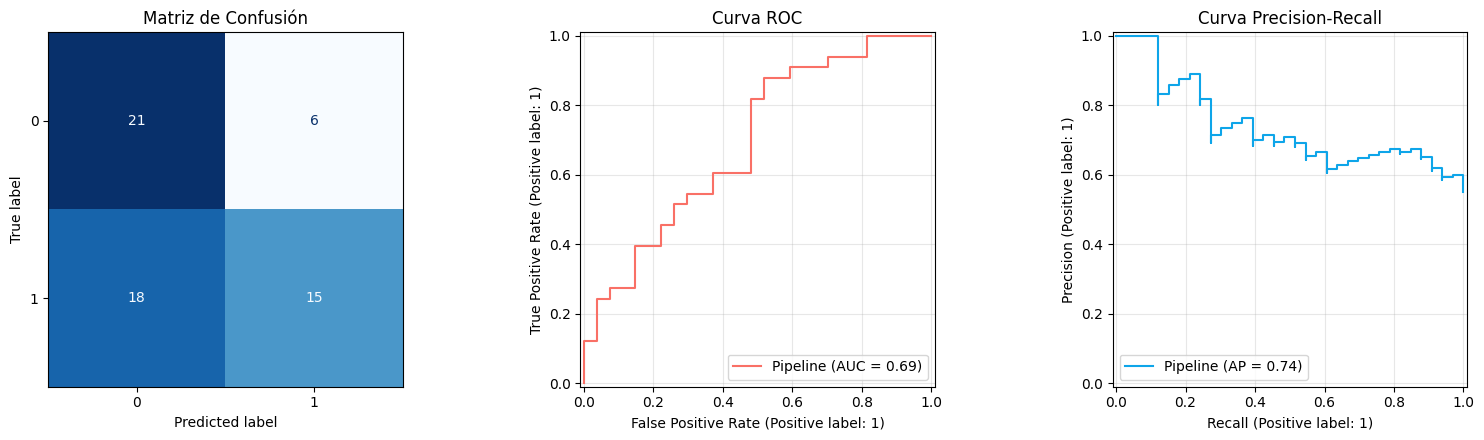

ROC-AUC: 0.692


In [5]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay, roc_auc_score
import matplotlib.pyplot as plt

# 1. Predicciones sobre el conjunto de prueba con el mejor pipeline
y_pred = mejor_pipeline.predict(X_test)

# 2. Precisión, recall y F1 por clase
print("Reporte de clasificación (conjunto de prueba):\n")
print(classification_report(y_test, y_pred))

# 3. Matriz de confusión, curva ROC y curva Precision-Recall, lado a lado
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ConfusionMatrixDisplay.from_estimator(mejor_pipeline, X_test, y_test, ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Matriz de Confusión")

RocCurveDisplay.from_estimator(mejor_pipeline, X_test, y_test, ax=axes[1], color="#F97066")
axes[1].set_title("Curva ROC")
axes[1].grid(True, alpha=0.3)

PrecisionRecallDisplay.from_estimator(mejor_pipeline, X_test, y_test, ax=axes[2], color="#0EA5E9")
axes[2].set_title("Curva Precision-Recall")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. AUC como número explícito (además de la curva)
y_proba = mejor_pipeline.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {auc:.3f}")

Con los resultados reales de <code>mejor_pipeline</code> sobre el conjunto de prueba: la clase 1 (<code>aprobado</code>) tiene una **precision** de 0.71 pero un **recall** de apenas 0.45 — de todas las solicitudes que en realidad deberían aprobarse, el modelo solo identifica correctamente el 45&nbsp;%. La clase 0 (<code>no aprobado</code>) muestra el patrón inverso: recall alto (0.78) pero precision más baja (0.54). La accuracy global (0.60) no deja ver ninguno de estos dos problemas por separado — un ejemplo concreto de por qué una sola cifra no basta para decidir si un modelo "es bueno": aquí, la respuesta depende de qué error preocupa más a la entidad bancaria. Si el costo de rechazar por error a un buen pagador (falso negativo de la clase 1) es alto, este modelo **todavía necesita mejorar** antes de usarse en producción, sin importar que su accuracy sea aceptable.

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
El ROC-AUC obtenido (0.692) resume, en un solo número, qué tan bien separa el modelo ambas clases considerando <em>todos</em> los umbrales posibles a la vez (0.5 = azar, 1.0 = separación perfecta) — bastante por encima del azar, pero lejos de una separación perfecta. A diferencia de precision, recall y F1 (que dependen del umbral 0.5 usado por defecto), el AUC no depende de ningún umbral en particular, pero tampoco garantiza que ese umbral por defecto sea el más conveniente para este problema: ajustarlo (por ejemplo, aprobar con una probabilidad predicha menor a 0.5) es una forma directa de mover el balance entre precision y recall de la clase 1 sin reentrenar el modelo.
</div>

---

<a id="curvas"></a>

# <span style="color:#F97066;">6.</span> Curvas de aprendizaje y de validación

Además de una única puntuación de validación cruzada, es útil observar **cómo cambia** el desempeño del pipeline en función de dos factores distintos: la cantidad de datos de entrenamiento disponibles (<code>learning_curve</code>) y la complejidad del modelo (<code>validation_curve</code>). Ambas funciones reciben el <code>Pipeline</code> completo, por lo que el preprocesamiento se reajusta correctamente en cada evaluación.

<span style="color:#F97066;">6.1</span> Curva de aprendizaje

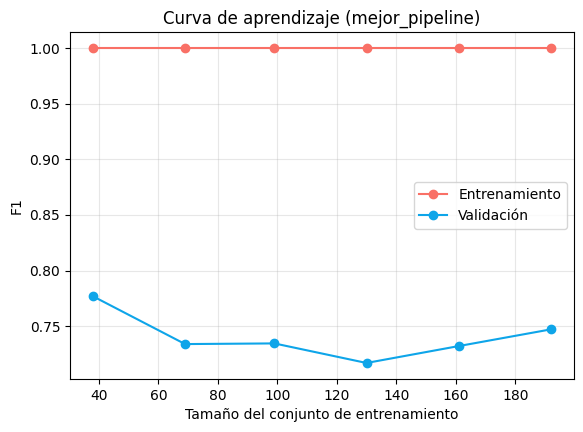

In [6]:
from sklearn.model_selection import learning_curve

# 1. Curva de aprendizaje: F1 en función del tamaño del conjunto de entrenamiento usado
train_sizes, train_scores, val_scores = learning_curve(
    mejor_pipeline, X_train, y_train, cv=cv_estratificado, scoring="f1",
    train_sizes=np.linspace(0.2, 1.0, 6), random_state=42
)

plt.figure(figsize=(6.5, 4.5))
plt.plot(train_sizes, train_scores.mean(axis=1), "o-", color="#F97066", label="Entrenamiento")
plt.plot(train_sizes, val_scores.mean(axis=1), "o-", color="#0EA5E9", label="Validación")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("F1")
plt.title("Curva de aprendizaje (mejor_pipeline)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<span style="color:#F97066;">6.2</span> Curva de validación

Se varía la profundidad máxima (<code>max_depth</code>) del <code>RandomForestClassifier</code> dentro del pipeline, para observar en qué punto el modelo empieza a sobreajustar (el desempeño en entrenamiento sigue subiendo, pero el de validación se estanca o empeora).

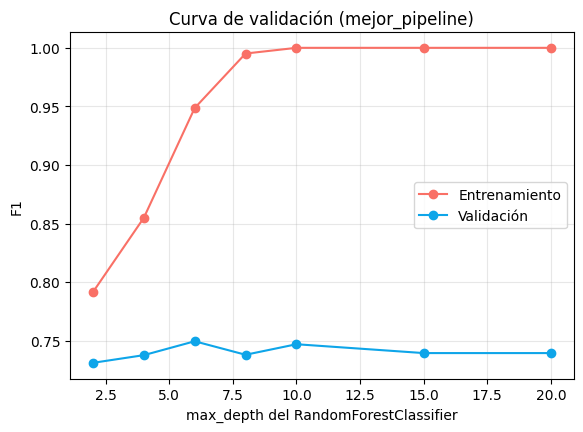

In [7]:
from sklearn.model_selection import validation_curve

# 1. Curva de validación: F1 en función de max_depth del clasificador dentro del pipeline
rango_max_depth = [2, 4, 6, 8, 10, 15, 20]
train_scores_vc, val_scores_vc = validation_curve(
    mejor_pipeline, X_train, y_train, param_name="classifier__max_depth",
    param_range=rango_max_depth, cv=cv_estratificado, scoring="f1"
)

plt.figure(figsize=(6.5, 4.5))
plt.plot(rango_max_depth, train_scores_vc.mean(axis=1), "o-", color="#F97066", label="Entrenamiento")
plt.plot(rango_max_depth, val_scores_vc.mean(axis=1), "o-", color="#0EA5E9", label="Validación")
plt.xlabel("max_depth del RandomForestClassifier")
plt.ylabel("F1")
plt.title("Curva de validación (mejor_pipeline)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---

<a id="desbalance"></a>

# <span style="color:#F97066;">7.</span> Clases desbalanceadas

<span style="color:#F97066;">7.1</span> Por qué accuracy engaña cuando las clases están desbalanceadas

Se genera un segundo dataset sintético, deliberadamente desbalanceado (95&nbsp;% / 5&nbsp;%), para mostrar un problema que el dataset de crédito (más balanceado) no deja ver con claridad.

In [8]:
from sklearn.datasets import make_classification
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, recall_score

# 1. Dataset sintético deliberadamente desbalanceado (95 % clase 0 / 5 % clase 1)
X_imb, y_imb = make_classification(
    n_samples=2000, n_features=10, n_informative=5,
    weights=[0.95, 0.05], flip_y=0.01, random_state=42,
)

print("Proporción de clases en el dataset completo:", np.round(np.bincount(y_imb) / len(y_imb), 3))

# 2. Dividir en entrenamiento y prueba, preservando la proporción de clases
X_imb_train, X_imb_test, y_imb_train, y_imb_test = train_test_split(
    X_imb, y_imb, test_size=0.3, random_state=42, stratify=y_imb
)

# 3. Clasificador "ingenuo": siempre predice la clase mayoritaria
clasificador_ingenuo = DummyClassifier(strategy="most_frequent")
clasificador_ingenuo.fit(X_imb_train, y_imb_train)
y_dummy_pred = clasificador_ingenuo.predict(X_imb_test)

print(f"\nAccuracy del clasificador ingenuo: {accuracy_score(y_imb_test, y_dummy_pred):.3f}")
print(f"Recall en la clase minoritaria:    {recall_score(y_imb_test, y_dummy_pred, pos_label=1):.3f}")

Proporción de clases en el dataset completo: [0.946 0.054]

Accuracy del clasificador ingenuo: 0.947
Recall en la clase minoritaria:    0.000


El clasificador ingenuo, que ni siquiera mira las variables de entrada, alcanza una accuracy alta simplemente por la proporción de clases — y un recall de 0&nbsp;% en la clase minoritaria, que suele ser precisamente la clase de interés (por ejemplo, detectar fraude o una enfermedad rara). Esto ilustra por qué, con clases desbalanceadas, conviene reportar métricas como recall, F1 o ROC-AUC de la clase minoritaria en lugar de (o además de) accuracy.

<span style="color:#F97066;">7.2</span> <code>SMOTE</code> dentro de un <code>imblearn.pipeline.Pipeline</code>

Una estrategia común para el desbalance es el sobremuestreo sintético de la clase minoritaria con <strong>SMOTE</strong> (*Synthetic Minority Over-sampling Technique*). SMOTE no es un <code>Transformer</code> de <code>scikit-learn</code> (también transforma <code>y</code>, generando nuevas filas), por lo que no puede incluirse en un <code>Pipeline</code> de <code>scikit-learn</code>; para eso, <code>imbalanced-learn</code> ofrece su propio <code>Pipeline</code> (<code>imblearn.pipeline.Pipeline</code>), con la misma interfaz pero capaz de incluir pasos de sobre/sub-muestreo.

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
SMOTE debe ir <strong>dentro</strong> del pipeline de cada fold de validación cruzada, y nunca aplicarse antes de dividir en entrenamiento/prueba (o en entrenamiento/validación). Es exactamente el mismo problema de fuga de datos que en <code>5-data-preprocessing.ipynb</code> con el escalado o la imputación, aplicado ahora al sobremuestreo: si se generan ejemplos sintéticos con el dataset completo y <strong>después</strong> se divide en folds, es posible que un ejemplo sintético en el fold de validación haya sido generado a partir de vecinos reales que quedaron en el fold de entrenamiento (o viceversa). El fold de validación dejaría de ser una muestra genuinamente "no vista", y las métricas de validación cruzada resultarían optimistas de forma artificial. Por eso <code>pipeline_con_smote</code>, más abajo, se pasa completo a <code>cross_validate</code>: SMOTE se reajusta y se aplica desde cero en cada fold, usando solo los datos de entrenamiento de ese fold.
</div>

In [9]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# 1. Pipeline SIN SMOTE: el clasificador se entrena directamente sobre los datos desbalanceados
pipeline_sin_smote = ImbPipeline(steps=[
    ("classifier", RandomForestClassifier(random_state=42)),
])

# 2. Pipeline CON SMOTE: el sobremuestreo se ajusta y aplica dentro de cada fold de validación cruzada
pipeline_con_smote = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(random_state=42)),
])

# 3. Comparar ambos pipelines con validación cruzada estratificada,
#    con métricas centradas en la clase minoritaria
cv_imb = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
metricas_imb = ["recall", "f1", "roc_auc"]

resultados_sin_smote = cross_validate(pipeline_sin_smote, X_imb_train, y_imb_train, cv=cv_imb, scoring=metricas_imb)
resultados_con_smote = cross_validate(pipeline_con_smote, X_imb_train, y_imb_train, cv=cv_imb, scoring=metricas_imb)

print("Sin SMOTE (clase minoritaria):")
for m in metricas_imb:
    print(f"  {m:9s}: {resultados_sin_smote[f'test_{m}'].mean():.3f}")

print("\nCon SMOTE (clase minoritaria):")
for m in metricas_imb:
    print(f"  {m:9s}: {resultados_con_smote[f'test_{m}'].mean():.3f}")

Sin SMOTE (clase minoritaria):
  recall   : 0.383
  f1       : 0.526
  roc_auc  : 0.918

Con SMOTE (clase minoritaria):
  recall   : 0.618
  f1       : 0.603
  roc_auc  : 0.921


Observe en particular el <strong>recall</strong> de la clase minoritaria: es la métrica donde el sobremuestreo con SMOTE suele mostrar el efecto más claro frente al pipeline entrenado directamente sobre los datos desbalanceados.

---

<a id="cierre"></a>

# <span style="color:#F97066;">🎯 Cierre y próximos pasos</span>

<div style="border-left:4px solid #14B8A6; background:rgba(20,184,166,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>✅ Resumen</strong><br>

- Por qué <code>Pipeline</code> evita la fuga de datos por construcción y simplifica el código, retomando el principio ya visto en <code>5-data-preprocessing.ipynb</code>.
- <code>ColumnTransformer</code> para aplicar imputación + escalado a columnas numéricas y <code>OneHotEncoder</code> a columnas categóricas, todo dentro de un único <code>Pipeline</code> junto con un clasificador.
- Validación cruzada estratificada (<code>StratifiedKFold</code> + <code>cross_validate</code>) del Pipeline completo, con varias métricas a la vez (accuracy, F1, ROC-AUC).
- <code>GridSearchCV</code> optimizando simultáneamente hiperparámetros de preprocesamiento (estrategia de imputación) y del modelo (<code>n_estimators</code>, <code>max_depth</code>).
- Métricas más allá de accuracy: matriz de confusión, <code>classification_report</code>, curva ROC y curva Precision-Recall.
- Curvas de aprendizaje y de validación para diagnosticar sub/sobreajuste.
- Por qué accuracy engaña con clases desbalanceadas, y cómo usar <code>SMOTE</code> dentro de un <code>imblearn.pipeline.Pipeline</code> (nunca antes de dividir en folds) para mejorar el recall de la clase minoritaria.

</div>

<div style="border:1px solid rgba(14,165,233,0.35); border-radius:10px; padding:14px 20px; margin:16px 0; background:rgba(14,165,233,0.04);">
<strong>➡️ Continúe con</strong>
<ul style="margin:8px 0 0; padding-left:20px;">
<li><code>../Unidad 4/1-fundamentos-redes-neuronales.ipynb</code> — este es el último notebook de la secuencia de profundización de la Unidad 3; la siguiente unidad del curso trata redes neuronales y arquitecturas modernas.</li>
</ul>
</div>